temperature: average temperature (f) in region  
Markdown: any promotional markdowns. available only after nov 2011.  
CPI: inflation indicator  
Unemplyment: unemplyment rate in region, affects spending  
Type A: Sizes from 39.690 to 219.622  
Type B: Sizes from 34.875 to 140.167  
Type C: Sizes from 39.690 to 42.988  

note: four holidays fall within  
Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13  
Labor Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13  
Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13  
Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13  

In [56]:
import pandas as pd
stores = pd.read_csv("stores.csv")
features = pd.read_csv("features.csv.zip")
sales = pd.read_csv("train.csv")
df = pd.merge(sales, features, on= ["Store", "Date"], how="left")
df = df.drop(columns=["IsHoliday_y"])
df = pd.merge(df, stores, on="Store", how="left")
df


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,B,118221


## Quick Cleaning

In [57]:
df.isna().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [58]:
#Only missing values are in markdown, which is because markdown information is only available after nov 11. Will fill these missing values with 0s.
markdown_cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
df[markdown_cols] = df[markdown_cols].fillna(0)

## EDA

In [59]:
#Which stores had the highest average weekly sales?
df.groupby("Store")["Weekly_Sales"].mean().nlargest(5)

Store
20    29508.301592
4     29161.210415
14    28784.851727
13    27355.136891
2     26898.070031
Name: Weekly_Sales, dtype: float64

In [60]:
#Lowest average weekly sales?
df.groupby("Store")["Weekly_Sales"].mean().nsmallest(5)

Store
5     5053.415813
33    5728.414053
44    6038.929814
3     6373.033983
38    7492.478460
Name: Weekly_Sales, dtype: float64

In [61]:
#How do holidays impact Weekly sales?
df.groupby("IsHoliday_x")["Weekly_Sales"].median()

IsHoliday_x
False    7589.95
True     7947.74
Name: Weekly_Sales, dtype: float64

In [62]:
#What about store type? 
df.groupby("Type")["Weekly_Sales"].mean()

Type
A    20099.568043
B    12237.075977
C     9519.532538
Name: Weekly_Sales, dtype: float64

In [63]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df.groupby("Year")["Weekly_Sales"].sum()

Year
2010    2.288886e+09
2011    2.448200e+09
2012    2.000133e+09
Name: Weekly_Sales, dtype: float64

# Regression

In [64]:
df



,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.00,0.00,0.00,0.00,0.00,211.096358,8.106,A,151315,2010
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.00,0.00,0.00,0.00,0.00,211.242170,8.106,A,151315,2010
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.00,0.00,0.00,0.00,0.00,211.289143,8.106,A,151315,2010
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.00,0.00,0.00,0.00,0.00,211.319643,8.106,A,151315,2010
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.00,0.00,0.00,0.00,0.00,211.350143,8.106,A,151315,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221,2012
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667,B,118221,2012
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667,B,118221,2012
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667,B,118221,2012


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["week"] = df["Date"].dt.isocalendar().week
df["day_of_week"] = df["Date"].dt.dayofweek
df_new = df.drop(columns=["Date", "Type"])
from sklearn.model_selection import train_test_split

X = df_new.drop(columns=["Weekly_Sales"])
y = df_new["Weekly_Sales"]
X = pd.get_dummies(X, columns=["Store", "Dept"], drop_first=True)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

First, want to predict weekly sales using regular linear regression.

In [ ]:
import statsmodels.formula.api as smf
results = smf.ols("Weekly_Sales~C(Store) + C(Dept) + IsHoliday_x + Temperature + Fuel_Price + MarkDown1 + MarkDown2 + MarkDown3 + MarkDown4 + MarkDown5 + CPI + Unemployment + Size + Year", data = df).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Weekly_Sales   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     6018.
Date:                Sat, 17 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:13:54   Log-Likelihood:            -4.6003e+06
No. Observations:              421570   AIC:                         9.201e+06
Df Residuals:                  421434   BIC:                         9.202e+06
Df Model:                         135                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            3.593e+06   1.41e+05     25.565      0.000    3.32e+06    3.87e+06
C(Store)[T.2]       -1.381e+05   5349.940    -25.820      0.000   -1.49e+05   -1.28e+05
C(Store)[T.3]        3.029e+05   1.19e+04     25.420      0.000     2.8e+05    3.26e+05
C(Store)[T.4]        -1.26e+05   5100.376    -24.703      0.000   -1.36e+05   -1.16e+05
C(Store)[T.5]        3.084e+05   1.22e+04     25.311      0.000    2.85e+05    3.32e+05
C(Store)[T.6]        -1.45e+05   5404.876    -26.822      0.000   -1.56e+05   -1.34e+05
C(Store)[T.7]        2.183e+05   8664.397     25.189      0.000    2.01e+05    2.35e+05
C(Store)[T.8]       -2.178e+04    497.143    -43.809      0.000   -2.28e+04   -2.08e+04
C(Store)[T.9]        5.545e+04   2621.793     21.149      0.000    5.03e+04    6.06e+04
C(Store)[T.10]       9.644e+04   3538.540     27.255      0.000    8.95e+04    1.03e+05
C(Store)[T.11]      -1.619e+05   5933.409    -27.278      0.000   -1.73e+05    -1.5e+05
C(Store)[T.12]       1.281e+05   5060.941     25.318      0.000    1.18e+05    1.38e+05
C(Store)[T.13]      -1.655e+05   6503.334    -25.456      0.000   -1.78e+05   -1.53e+05
C(Store)[T.14]      -1.247e+05   4950.525    -25.197      0.000   -1.34e+05   -1.15e+05
C(Store)[T.15]       8.401e+04   3730.004     22.524      0.000    7.67e+04    9.13e+04
C(Store)[T.16]        2.54e+05      1e+04     25.287      0.000    2.34e+05    2.74e+05
C(Store)[T.17]       1.745e+05   6925.420     25.195      0.000    1.61e+05    1.88e+05
C(Store)[T.18]       1.003e+05   4059.856     24.693      0.000    9.23e+04    1.08e+05
C(Store)[T.19]      -1.296e+05   4912.503    -26.374      0.000   -1.39e+05    -1.2e+05
C(Store)[T.20]      -1.384e+05   5461.949    -25.333      0.000   -1.49e+05   -1.28e+05
C(Store)[T.21]       2.033e+04   1186.931     17.128      0.000     1.8e+04    2.27e+04
C(Store)[T.22]       1.009e+05   4114.921     24.526      0.000    9.29e+04    1.09e+05
C(Store)[T.23]       1.183e+05   4624.207     25.584      0.000    1.09e+05    1.27e+05
C(Store)[T.24]      -1.304e+05   4902.864    -26.602      0.000    -1.4e+05   -1.21e+05
C(Store)[T.25]       5.449e+04   2483.969     21.936      0.000    4.96e+04    5.94e+04
C(Store)[T.26]       8227.4763   1153.153      7.135      0.000    5967.332    1.05e+04
C(Store)[T.27]      -1.269e+05   4974.175    -25.511      0.000   -1.37e+05   -1.17e+05
C(Store)[T.28]      -1.322e+05   5023.026    -26.315      0.000   -1.42e+05   -1.22e+05
C(Store)[T.29]        1.69e+05   6860.615     24.632      0.000    1.56e+05    1.82e+05
C(Store)[T.30]        2.87e+05   1.14e+04     25.243      0.000    2.65e+05    3.09e+05
C(Store)[T.31]      -1.496e+05   5500.494    -27.200      0.000    -1.6e+05   -1.39e+05
C(Store)[T.32]      -1.449e+05   5222.968    -27.738      0.000   -1.55e+05   -1.35e+05
C(S

We have a moderately strong r2, but multicollinearity may be present. We can check this with a correlation matrix.

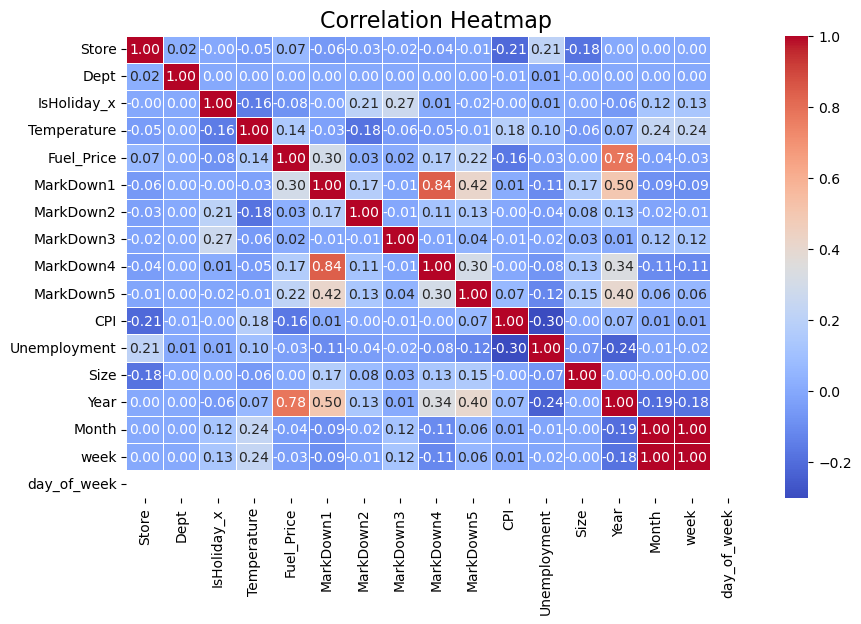

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
predictors = df.drop("Weekly_Sales", axis = 1)
corr_matrix = predictors.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

Two concerning correlation coefficients between markdown 4 and 1, and fuel price and year. Now, I will use different regularization techniques, for handling multicollinearity and feature selection. I expect Elastic Net and Ridge to be more helpful as there is multicollinearity present in the data.

In [69]:
from sklearn.preprocessing import StandardScaler
scaler_training = StandardScaler()
scaled_x_train = scaler_training.fit_transform(X_train)
X_train_scaled = pd.DataFrame(scaled_x_train, columns = X_train.columns)
X_val_scaled = scaler_training.transform(X_val)

In [99]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

en_mod_1 = ElasticNet(alpha=0.4, l1_ratio=0.7)
en_mod_1.fit(X_train_scaled, y_train)

rmse = mean_squared_error(y_val, en_mod_1.predict(X_val_scaled), squared=False)
r2 = r2_score(y_val, en_mod_1.predict(X_val_scaled))

print("RMSE:", rmse)
print("R^2:", r2)

RMSE: 13539.00373157279
R^2: 0.648485487117955


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(


In [100]:
from sklearn.linear_model import ElasticNet
en_mod_2 = ElasticNet(alpha=0.2, l1_ratio= 0.7)
en_mod_2.fit(X_train_scaled, y_train)

rmse2 = mean_squared_error(y_val, en_mod_2.predict(X_val_scaled), squared=False)
r2 = r2_score(y_val, en_mod_2.predict(X_val_scaled))

print("RMSE:", rmse2)
print("R^2:", r2)


RMSE: 13422.655325038093
R^2: 0.6545010586676918


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(


In [89]:

from sklearn.metrics import mean_squared_error
mean_squared_error(y_val, en_mod_2.predict(X_val_scaled), squared=False)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


13539.00373157279

In [101]:
en_mod_3 = ElasticNet(alpha=0.1, l1_ratio=0.7)
en_mod_3.fit(X_train_scaled, y_train)

rmse3 = mean_squared_error(y_val, en_mod_3.predict(X_val_scaled), squared=False)
r2 = r2_score(y_val, en_mod_3.predict(X_val_scaled))

print("RMSE:", rmse3)
print("R^2:", r2)

RMSE: 13381.087548642095
R^2: 0.6566376530431532


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(


In [102]:
en_mod_4 = ElasticNet(alpha=0.05, l1_ratio=0.7)
en_mod_4.fit(X_train_scaled, y_train)

rmse4 = mean_squared_error(y_val, en_mod_4.predict(X_val_scaled), squared=False)
r2 = r2_score(y_val, en_mod_4.predict(X_val_scaled))

print("RMSE:", rmse4)
print("R^2:", r2)

RMSE: 13364.856598549683
R^2: 0.6574701290400096


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(


Elastic Net didn't significantly impact the r2. We will compare the model's performance with other regression methods, ridge and lasso.

In [103]:
from sklearn.linear_model import Ridge
ridge_mod_1 = Ridge(alpha=1, max_iter=1000)
ridge_mod_1.fit(X_train_scaled.values, y_train)

rmse = mean_squared_error(y_val, ridge_mod_1.predict(X_val_scaled), squared=False)
r2 = r2_score(y_val, ridge_mod_1.predict(X_val_scaled))

print("RMSE:", rmse)
print("R^2:", r2)


RMSE: 13353.469244983753
R^2: 0.658053576685661


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [105]:
ridge_mod_25 = Ridge(alpha=2.5, max_iter=1000)
ridge_mod_25.fit(X_train_scaled.values, y_train)

rmse2 = mean_squared_error(y_val, ridge_mod_25.predict(X_val_scaled), squared=False)
r2 = r2_score(y_val, ridge_mod_25.predict(X_val_scaled))

print("RMSE:", rmse2)
print("R^2:", r2)

RMSE: 13353.47039795661
R^2: 0.6580535176365923


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [106]:
ridge_mod_5 = Ridge(alpha=5, max_iter=1000)
ridge_mod_5.fit(X_train_scaled.values, y_train)

rmse3 = mean_squared_error(y_val, ridge_mod_5.predict(X_val_scaled), squared=False)
r2 = r2_score(y_val, ridge_mod_5.predict(X_val_scaled))

print("RMSE:", rmse3)
print("R^2:", r2)

RMSE: 13353.472384602534
R^2: 0.6580534158912608


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [107]:
ridge_mod_10 = Ridge(alpha=10, max_iter=1000)
ridge_mod_10.fit(X_train_scaled.values, y_train)

rmse4 = mean_squared_error(y_val, ridge_mod_10.predict(X_val_scaled), squared=False)
r2 = r2_score(y_val, ridge_mod_10.predict(X_val_scaled))

print("RMSE:", rmse4)
print("R^2:", r2)

RMSE: 13353.476567610564
R^2: 0.6580532016600122


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [108]:
df_slopes = pd.DataFrame({
    "ridge_1": ridge_mod_1.coef_,
    "ridge_25": ridge_mod_25.coef_,
    "ridge_5": ridge_mod_5.coef_, 
    "ridge_10": ridge_mod_10.coef_
}, index=X_train.columns)
df_slopes

,ridge_1,ridge_25,ridge_5,ridge_10
IsHoliday_x,62.127768,62.107241,62.073991,62.010799
Temperature,-458.580667,-458.534022,-458.458115,-458.312583
Fuel_Price,99.802099,99.741950,99.645114,99.463095
MarkDown1,176.703932,176.745421,176.812226,176.937792
MarkDown2,-193.903612,-193.891186,-193.871896,-193.838164
...,...,...,...,...
Dept_95,6175.590927,6175.712677,6175.915353,6176.319818
Dept_96,-412.639207,-412.509335,-412.292976,-411.860643
Dept_97,-623.421738,-623.272783,-623.024710,-622.529261
Dept_98,-1523.481137,-1523.332571,-1523.085208,-1522.591386


R^2 is slightly better with ridge than elastic net, and around the same as regular linear regression. So far this model is most useful as its results account for multicollinearity in the variables and also performs well. Next, we will do Lasso for feature selection.

In [110]:
from sklearn.linear_model import Lasso
lasso_mod_50 = Lasso(alpha=50, max_iter=5000)
lasso_mod_50.fit(X_train_scaled, y_train)

rmse = mean_squared_error(y_val, lasso_mod_50.predict(X_val_scaled), squared=False)
r2 = r2_score(y_val, lasso_mod_50.predict(X_val_scaled))

print("RMSE:", rmse)
print("R^2:", r2)


RMSE: 13405.762858148373
R^2: 0.6553701351303385


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.linear_model import Lasso
lasso_mod_10 = Lasso(alpha=10, max_iter=1000)
lasso_mod_10.fit(X_train_scaled, y_train)

rmse2 = mean_squared_error(y_val, lasso_mod_10.predict(X_val_scaled), squared=False)
r2 = r2_score(y_val, lasso_mod_10.predict(X_val_scaled))

print("RMSE:", rmse2)
print("R^2:", r2)

RMSE: 13360.27812435361
R^2: 0.6577047736154252


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.linear_model import Lasso
lasso_mod_5 = Lasso(alpha=5, max_iter=1000)
lasso_mod_5.fit(X_train_scaled, y_train)

rmse3 = mean_squared_error(y_val, lasso_mod_5.predict(X_val_scaled), squared=False)
r2 = r2_score(y_val, lasso_mod_5.predict(X_val_scaled))

print("RMSE:", rmse3)
print("R^2:", r2)

RMSE: 13355.810027983347
R^2: 0.6579336838676375


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [112]:
from sklearn.linear_model import Lasso
lasso_mod_25 = Lasso(alpha=2.5, max_iter=1000)
lasso_mod_25.fit(X_train_scaled, y_train)

rmse4 = mean_squared_error(y_val, lasso_mod_25.predict(X_val_scaled), squared=False)
r2 = r2_score(y_val, lasso_mod_25.predict(X_val_scaled))

print("RMSE:", rmse4)
print("R^2:", r2)

RMSE: 13354.225667817613
R^2: 0.6580148356807964


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [113]:
df_slopes = pd.DataFrame({
                         'lasso_mod_50': lasso_mod_50.coef_.T,
                         'lasso_mod_10': lasso_mod_10.coef_.T,
                         'lasso_mod_5': lasso_mod_5.coef_.T,
                         'lasso_mod_25': lasso_mod_25.coef_.T,}, index=X_train.columns)
df_slopes

,lasso_mod_50,lasso_mod_10,lasso_mod_5,lasso_mod_25
IsHoliday_x,15.334905,43.899993,50.850163,56.029442
Temperature,-270.941443,-408.513357,-433.321181,-444.608078
Fuel_Price,-12.204548,0.000000,44.921480,70.907077
MarkDown1,40.333351,93.345912,137.004344,157.779572
MarkDown2,-95.406147,-182.390550,-189.813088,-190.995443
...,...,...,...,...
Dept_95,6817.600342,6461.088875,6318.311035,6251.947946
Dept_96,136.316606,-146.131166,-279.470621,-341.737896
Dept_97,10.054490,-322.133615,-472.846424,-543.239773
Dept_98,-816.879933,-1233.091320,-1378.319082,-1446.156240


In [114]:
lasso_slopes_5 = df_slopes["lasso_mod_5"]
lasso_nonzero = lasso_slopes_5[lasso_slopes_5 == 0]
lasso_nonzero = lasso_nonzero.sort_values(key=abs, ascending=False)
lasso_nonzero

day_of_week    0.0
Store_2       -0.0
Store_27       0.0
Store_38      -0.0
Name: lasso_mod_5, dtype: float64

Chose alpha = 5 so we have moderate penalty and r2 is not significantly affected. Lasso was not much helpful, as expected, as it deemed day of week and stores 2, 27, 38 to have no affect on the model.

In [86]:
df_new

,Store,Dept,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Year,Month,week,day_of_week
0,1,1,24924.50,False,42.31,2.572,0.00,0.00,0.00,0.00,0.00,211.096358,8.106,151315,2010,2,5,4
1,1,1,46039.49,True,38.51,2.548,0.00,0.00,0.00,0.00,0.00,211.242170,8.106,151315,2010,2,6,4
2,1,1,41595.55,False,39.93,2.514,0.00,0.00,0.00,0.00,0.00,211.289143,8.106,151315,2010,2,7,4
3,1,1,19403.54,False,46.63,2.561,0.00,0.00,0.00,0.00,0.00,211.319643,8.106,151315,2010,2,8,4
4,1,1,21827.90,False,46.50,2.625,0.00,0.00,0.00,0.00,0.00,211.350143,8.106,151315,2010,3,9,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,118221,2012,9,39,4
421566,45,98,628.10,False,64.89,3.985,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667,118221,2012,10,40,4
421567,45,98,1061.02,False,54.47,4.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667,118221,2012,10,41,4
421568,45,98,760.01,False,56.47,3.969,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667,118221,2012,10,42,4


In [87]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,week,day_of_week
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.00,0.00,0.00,0.00,0.00,211.096358,8.106,A,151315,2010,2,5,4
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.00,0.00,0.00,0.00,0.00,211.242170,8.106,A,151315,2010,2,6,4
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.00,0.00,0.00,0.00,0.00,211.289143,8.106,A,151315,2010,2,7,4
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.00,0.00,0.00,0.00,0.00,211.319643,8.106,A,151315,2010,2,8,4
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.00,0.00,0.00,0.00,0.00,211.350143,8.106,A,151315,2010,3,9,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221,2012,9,39,4
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667,B,118221,2012,10,40,4
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667,B,118221,2012,10,41,4
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667,B,118221,2012,10,42,4


In [88]:
final_df = df
final_df["lin_reg_pred"] = results.predict(df)
final_df.to_csv("final_csv.csv", index=False)
final_df
# created csv with linear regression predicted sales values for dashboard in power bi


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,week,day_of_week,lin_reg_pred
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.00,0.00,0.00,...,0.00,211.096358,8.106,A,151315,2010,2,5,4,26997.891383
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.00,0.00,0.00,...,0.00,211.242170,8.106,A,151315,2010,2,6,4,27575.270433
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.00,0.00,0.00,...,0.00,211.289143,8.106,A,151315,2010,2,7,4,27058.032679
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.00,0.00,0.00,...,0.00,211.319643,8.106,A,151315,2010,2,8,4,26955.961662
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.00,0.00,0.00,...,0.00,211.350143,8.106,A,151315,2010,3,9,4,27006.489598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,...,3288.25,192.013558,8.684,B,118221,2012,9,39,4,2584.740379
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,0.00,18.82,...,2340.01,192.170412,8.667,B,118221,2012,10,40,4,2593.232858
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,0.00,7.89,...,3990.54,192.327265,8.667,B,118221,2012,10,41,4,2856.819741
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,0.00,3.18,...,1537.49,192.330854,8.667,B,118221,2012,10,42,4,2691.351273


Summary of Regression Analysis:

- Linear regression achieved moderate r2
- Ridge and Elastic Net improved generalization and handled multicollinearity
- Lasso identified key predictors by shrinking non-influential coefficients to zero